In [1]:
# ============================================================
# LIBRARIAT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Lexo dataset-et
df      = pd.read_csv("../data/processed/laliga_master.csv")
df_pca  = pd.read_csv("../data/processed/laliga_pca.csv")
df_elo  = pd.read_csv("../data/processed/laliga_elo.csv")

# Bashko te gjitha
df = df.merge(df_pca, on=["Squad", "sezoni"], how="left")
df = df.merge(df_elo,  on=["Squad", "sezoni"], how="left")

print("Dimensionet:", df.shape)
print("OK!")

Dimensionet: (420, 37)
OK!


In [2]:
# ============================================================
# MODEL — PARASHIKO PTS NGA PC1, PC2, PC3
# ============================================================

# Filtro vetem rreshtat me PC1, PC2, PC3
df_model = df[["Squad", "sezoni", "Pts", "PC1", "PC2", "PC3"]].dropna()

# Variablat hyrëse dhe dalëse
X = df_model[["PC1", "PC2", "PC3"]].values
y = df_model["Pts"].values

# Trajno modelin
model = LinearRegression()
model.fit(X, y)

# Saktësia e modelit
r2 = model.score(X, y)

print("=== MODELI I PARASHIKIMIT ===")
print(f"R² = {r2:.4f} ({r2*100:.2f}%)")
print()
print("Koeficientët:")
for kolona, koef in zip(["PC1", "PC2", "PC3"], model.coef_):
    print(f"  {kolona}: {koef:+.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

=== MODELI I PARASHIKIMIT ===
R² = 0.9287 (92.87%)

Koeficientët:
  PC1: +6.3109
  PC2: +2.2017
  PC3: -0.8157
  Intercept: 52.0250


In [3]:
# ============================================================
# MONTE CARLO FINAL ME PCA
# ============================================================

N_SIMULIME     = 10000
ekipet_stabile = df_model["Squad"].unique().tolist()

# Mesatarja dhe kovarianca e PC1, PC2, PC3 per cdo ekip
mesataret_pca  = {}
kovariancet_pca = {}

for ekip in ekipet_stabile:
    df_ekip = df_model[df_model["Squad"] == ekip][["PC1", "PC2", "PC3"]]
    if len(df_ekip) >= 3:
        mesataret_pca[ekip]   = df_ekip.mean().values
        kovariancet_pca[ekip] = df_ekip.cov().values

# Gjenero simulimet
simulimet_pca = {}
for ekip in mesataret_pca:
    pc_simulate = np.random.multivariate_normal(
        mesataret_pca[ekip],
        kovariancet_pca[ekip],
        size=N_SIMULIME
    )
    # Parashiko Pts nga PC1, PC2, PC3
    simulimet_pca[ekip] = model.predict(pc_simulate)

# Gjej kampionin per cdo simulim
df_sim = pd.DataFrame(simulimet_pca)
kampionet_sim = df_sim.idxmax(axis=1)

# Probabilitetet
prob_final = kampionet_sim.value_counts(normalize=True).sort_values(ascending=False)

print("=== MONTE CARLO FINAL — PROBABILITETI I KAMPIONIT ===")
for ekip, prob in prob_final.items():
    print(f"{ekip:25} {prob:.3f} ({prob*100:.1f}%)")

=== MONTE CARLO FINAL — PROBABILITETI I KAMPIONIT ===
Barcelona                 0.553 (55.3%)
Real Madrid               0.417 (41.7%)
Atletico Madrid           0.025 (2.5%)
Sevilla                   0.002 (0.2%)
Girona                    0.002 (0.2%)
Osasuna                   0.000 (0.0%)
Malaga                    0.000 (0.0%)
Villarreal                0.000 (0.0%)
Valladolid                0.000 (0.0%)
Athletic Club             0.000 (0.0%)


C:\Users\user\AppData\Local\Temp\ipykernel_13504\1964178947.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(prob_plot.index, rotation=20, ha="right")


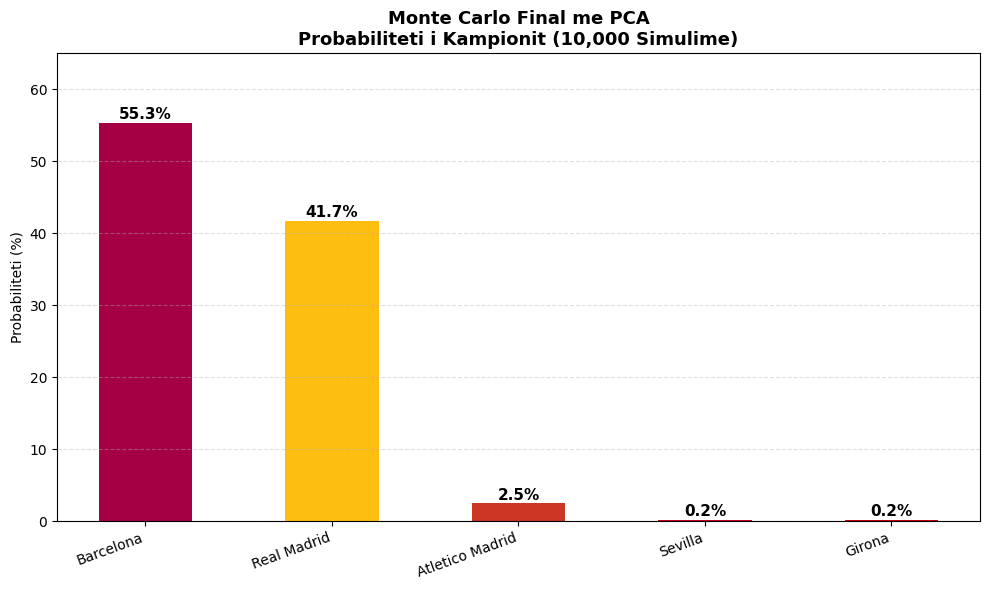

Grafiku u ruajt!


In [4]:
# ============================================================
# GRAFIKU FINAL — MONTE CARLO ME PCA
# ============================================================

# Filtro vetem ekipet me prob > 0
prob_plot = prob_final[prob_final > 0.001]

ngjyrat = {
    "Barcelona"      : "#A50044",
    "Real Madrid"    : "#FEBE10",
    "Atletico Madrid": "#CB3524",
    "Sevilla"        : "#D2001A",
    "Girona"         : "#CD0000",
    "Villarreal"     : "#FFD700",
    "Athletic Club"  : "#EE7203"
}

fig, ax = plt.subplots(figsize=(10, 6))

barras_ngjyrat = [ngjyrat.get(e, "steelblue") for e in prob_plot.index]

bars = ax.bar(prob_plot.index,
              prob_plot.values * 100,
              color=barras_ngjyrat, width=0.5)

for bar, val in zip(bars, prob_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val*100:.1f}%",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Probabiliteti (%)")
ax.set_title("Monte Carlo Final me PCA\nProbabiliteti i Kampionit (10,000 Simulime)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(prob_plot.index, rotation=20, ha="right")
ax.set_ylim(0, 65)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/19_monte_carlo_final.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")